# Spotiflow in Python

<div class="custom-button-row">
    <a 
        class="custom-button custom-download-button" href="../../../notebooks/05_segmentation/deep_learning/spot_detection_with_spotiflow.ipynb" download>
        <i class="fas fa-download"></i> Download this Notebook
    </a>
    <a
    class="custom-button custom-download-button" href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/05_segmentation/deep_learning/spot_detection_with_spotiflow_colab.ipynb" target="_blank">
        <img class="button-icon" src="../../../_static/logo/icon-google-colab.svg" alt="Open in Colab">
        Open in Colab
    </a>
</div>

In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "matplotlib",
#     "spotiflow",
#     "ndv[jupyter,pygfx]",
#     "jupyter-rfb<=0.5.4",
# ]
# ///

In [54]:
import csv

import matplotlib.pyplot as plt
import ndv
import numpy as np
import tifffile
from spotiflow.model import Spotiflow
from spotiflow.sample_data import test_image_hybiss_2d

This is a function that we will use later to save the detected spots as a `napari`-compatible `csv` file.

In [55]:
def save_points_as_csv(points, output_path="points.csv") -> None:
    """Save points as a napari-compatible CSV (drag-and-drop as Points layer)."""
    ndim = points.shape[1]
    headers = ["index"] + [f"axis-{i}" for i in range(ndim)]
    with open(output_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        for i, p in enumerate(points):
            writer.writerow([i, *p])

### Load the Image

In [46]:
image_path = "../../../_static/images/spots/2d_spots.tif"
image = tifffile.imread(image_path)

print(image.shape)

(256, 256)


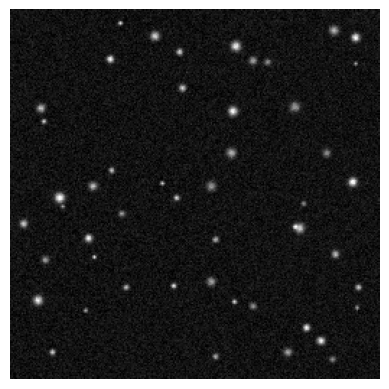

In [47]:
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [48]:
# Load a pretrained model
model = Spotiflow.from_pretrained("general")
# Or load your own trained model from folder
# model = Spotiflow.from_folder("./mymodel")

INFO:spotiflow.model.spotiflow:Loading pretrained model: general


In [49]:
# Predict
points, details = model.predict(image)

INFO:spotiflow.model.spotiflow:Will use device: mps:0
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.49999999999999994], min_distance = 1
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (256, 256)
INFO:spotiflow.model.spotiflow:Predicting with (1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (256, 256, 1)
INFO:spotiflow.model.spotiflow:Found 50 spots


points contains the coordinates of the detected spots, the attributes 'heatmap' and 'flow' of `details` contain the predicted full resolution heatmap and the prediction of the stereographic flow respectively (access them by `details.heatmap` or `details.flow`). Retrieved spot intensities are found in `details.intens`.

In [50]:
points.shape

(50, 2)

In [51]:
print(points[0])

[241.98516705 222.96446102]


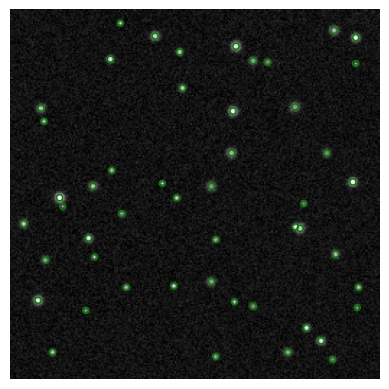

In [52]:
points_y = points[:, 0]
points_x = points[:, 1]

plt.imshow(image, cmap="gray")
plt.scatter(points_x, points_y, s=20, edgecolor="g", facecolor="none")
plt.axis("off")
plt.show()

In [ ]:
save_points_as_csv(points, "2d_points.csv")

In [10]:
ndv.imshow(details.heatmap, default_lut={"cmap": "hot"})

RFBOutputContext()

<IPython.core.display.Javascript object>

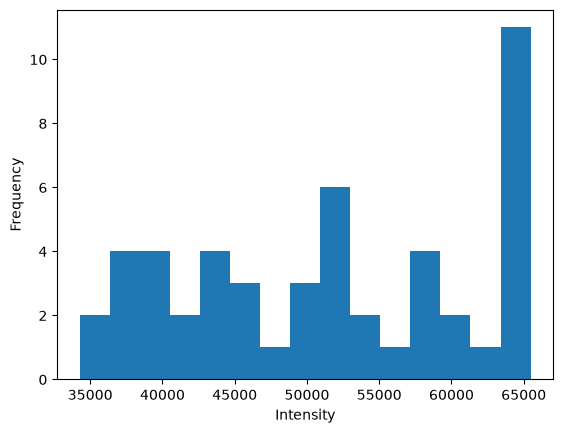

In [64]:
plt.hist(details.intens, bins=15)
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

## 3D

In [81]:
image_path = "../../../_static/images/spots/3d_spots.tif"
image_3d = tifffile.imread(image_path)

print(image_3d.shape)

(256, 256, 256)


In [82]:
ndv.imshow(image_3d)

RFBOutputContext()

<IPython.core.display.Javascript object>

In [83]:
# Load a pretrained model
model = Spotiflow.from_pretrained("smfish_3d")

INFO:spotiflow.model.spotiflow:Loading pretrained model: smfish_3d


In [84]:
points, details = model.predict(image_3d)

INFO:spotiflow.model.spotiflow:Will use device: cpu
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.4], min_distance = 1
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (256, 256, 256)
INFO:spotiflow.model.spotiflow:Predicting with (2, 1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (256, 256, 256, 1)
INFO:spotiflow.model.spotiflow:Correcting internal min_distance to 0.5 due to grid: (2, 2, 2).


Predicting tiles:   0%|          | 0/2 [00:00<?, ?it/s]

INFO:spotiflow.model.spotiflow:Found 50 spots


In [85]:
points[0]

array([119.02334154, 133.99904844, 203.01079941])

In [86]:
# save_points_as_csv(points, "points_3d.csv")
save_points_as_csv(points, "../../../_static/images/spots/3d_spots.csv")

In [87]:
ndv.imshow(details.heatmap, default_lut={"cmap": "hot"})

RFBOutputContext()

<IPython.core.display.Javascript object>

In [33]:
masked_heatmap = np.where(details.heatmap > 0.6, details.heatmap, 0)
ndv.imshow(masked_heatmap, default_lut={"cmap": "hot"})

RFBOutputContext()

<IPython.core.display.Javascript object>

In [69]:
img = test_image_hybiss_2d()

In [10]:
from skimage.feature import blob_log, peak_local_max
from skimage.filters import gaussian

152 spots detected

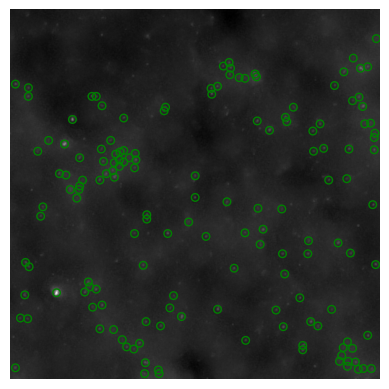

In [24]:
# --- simple local-maxima ("find maxima") ---
# peak_local_max is the direct analog of ImageJ's "Find Maxima." Big-FISH / FISH-quant essentially wrap LoG filtering + local maxima + a fitted threshold.
smoothed = gaussian(img, sigma=1)
coords = peak_local_max(
    smoothed,
    min_distance=3,
    # threshold_abs=0.02
    threshold_rel=0.61,
)

print(len(coords), "spots detected")
plt.imshow(img, cmap="gray")
plt.scatter(coords[:, 1], coords[:, 0], s=30, edgecolor="g", facecolor="none")
plt.axis("off")
plt.show()

91 spots detected

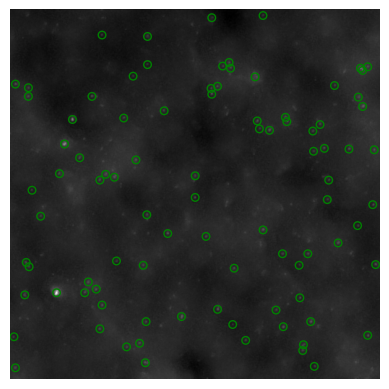

In [35]:
# --- LoG blob detection (handles spot size/scale) ---
# blobs: array of (row, col, sigma); radius ≈ sqrt(2)*sigma
blobs = blob_log(
    img,
    min_sigma=1,
    max_sigma=10,
    num_sigma=10,
    threshold=0.001,
)

print(len(blobs), "spots detected")
plt.imshow(img, cmap="gray")
plt.scatter(blobs[:, 1], blobs[:, 0], s=30, edgecolor="g", facecolor="none")
plt.axis("off")
plt.show()

In [141]:
import tifffile

img3d = tifffile.imread(
    "/Users/fdrgsp/Documents/git/bobiac-book/_internal/3d_spots.tif"
)

In [142]:
ndv.imshow(img3d)

RFBOutputContext()

<IPython.core.display.Javascript object>

In [143]:
img3d_smooth = gaussian(img3d, sigma=1)
ndv.imshow(img3d_smooth.astype("float32"))

RFBOutputContext()

<IPython.core.display.Javascript object>

In [144]:
scale_x, scale_y, scale_z = 0.1, 0.1, 0.5
anisotropy = scale_z / scale_x
print("Voxel anisotropy (z/xy):", anisotropy)

# peak_local_max keeps a pixel only if it is the maximum within this footprint,
# so the footprint sets the *minimum separation* between detected peaks (it does
# NOT change which spot sizes can be detected). For a 3D anisotropic stack we want
# the footprint to span the same *physical* distance in every axis.
#
# CASE 1 - a physically round object (bead, nucleus): same size in µm in all axes.
# Since z-voxels are `anisotropy` times larger, the object spans `anisotropy` times
# fewer voxels in z, so the footprint must be `anisotropy` times WIDER in xy:
#     footprint_xy / footprint_z = anisotropy            (= 5 here)
#
# CASE 2 - a diffraction-limited PSF spot (our data): the PSF is itself elongated
# in z (sigma_z is ~psf_z_elong times larger than sigma_xy in µm). That partially
# cancels the voxel anisotropy, so the spot is only ~1.75x wider in xy, NOT 5x:
#     footprint_xy / footprint_z = anisotropy / psf_z_elong = 5 / 2.86 ≈ 1.75

# PSF z-elongation from the Gaussian-PSF approximation (NA=0.75, RI=1, em=0.52 µm)
na, ri, em = 0.75, 1.0, 0.520
psf_z_elong = (0.45 * em * ri / na**2) / (0.21 * em / na)  # ≈ 2.86
xy_over_z = anisotropy / psf_z_elong  # ≈ 1.75
print(
    "PSF z-elongation:",
    round(psf_z_elong, 2),
    "-> footprint xy/z:",
    round(xy_over_z, 2),
)

# size the footprint to the spot's z-extent in voxels (measured ~9 here),
# then make xy `xy_over_z` times wider
n = 9
footprint = np.ones((n, round(n * xy_over_z), round(n * xy_over_z)), dtype=bool)
print("Footprint shape (z, y, x):", footprint.shape)

coords = peak_local_max(
    img3d_smooth,
    footprint=footprint,
    threshold_rel=0.2,
    # threshold_abs=0.1
)
print(len(coords), "spots detected")

Voxel anisotropy (z/xy): 5.0
PSF z-elongation: 2.86 -> footprint xy/z: 1.75
Footprint shape (z, y, x): (9, 16, 16)
50 spots detected


In [146]:
# For anisotropic voxels you pass blob_log a per-axis sigma tuple (z, y, x).
# Same correction as the footprint above: the z-sigma is NOT xy_sigma / anisotropy
# (that assumes a physically round object). For a diffraction-limited PSF the spot
# is z-elongated, so the voxel ratio is xy_over_z = anisotropy / psf_z_elong ≈ 1.75
# (psf_z_elong and xy_over_z were computed in the peak_local_max cell above).
# img3d is a 3D z-stack (Z, Y, X)

# xy-sigma range to scan, in xy voxels (smallest..largest spot)
min_xy, max_xy = 1.5, 6
min_sigma = max_sigma = (min_xy / xy_over_z, min_xy, min_xy)  # z uses PSF ratio

blobs = blob_log(
    img3d_smooth,
    min_sigma=min_sigma,
    max_sigma=max_sigma,
    num_sigma=10,
    threshold_rel=0.05,  # 8% of max blob intensity (lower = more spots, higher = fewer spots
)
print(len(blobs), "spots detected")

34 spots detected
